# ML Ensemble Models for IoT IDS

## Models Implemented:
1. **Random Forest** - Bagging ensemble
2. **XGBoost** - Gradient boosting ensemble
3. **CatBoost** - Gradient boosting ensemble with categorical features support

## Evaluation Metrics:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC, PR-AUC
- Confusion Matrix
- Classification Report

In [9]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, average_precision_score, confusion_matrix,
                            classification_report, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

In [10]:
np.random.seed(42)
RANDOM_STATE = 42

## 1. Data Loading and Preprocessing

Load the preprocessed data from the data preprocessing notebook.


In [11]:
# Load the preprocessed data
def load_preprocessed_data():
    # This loads the data that was saved from the CSI4999_dataPreprocessing.ipynb notebook.
    try:
        # Load the preprocessed train and test data
        X_train = pd.read_csv('data/preprocessedTrain1.csv')
        X_test = pd.read_csv('data/preprocessedTest1.csv')

        print("Preprocessed data loaded successfully!")
        print(f"Train data shape: {X_train.shape}")
        print(f"Test data shape: {X_test.shape}")

        print(f"\nColumns in train data: {list(X_train.columns)}")

        # Separate features and target
        benign = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
        y_train = X_train.pop('Attack_type')
        y_train = pd.DataFrame([0 if x in benign else 1 for x in y_train]).squeeze()

        y_test = X_test.pop('Attack_type')
        y_test = pd.DataFrame([0 if x in benign else 1 for x in y_test]).squeeze()

        print(f"\nFeatures shape: {X_train.shape}")
        print(f"Target shape: {y_train.shape}")

        return X_train, X_test, y_train, y_test

    except FileNotFoundError as e:
        print(f"Error loading preprocessed data: {e}")
        print("Please make sure you have run the CSI4999_dataPreprocessing.ipynb notebook first.")
        print("Expected files: data/preprocessedTrain.csv and data/preprocessedTest.csv")
        return None, None, None, None

X_train, X_test, y_train, y_test = load_preprocessed_data()

Preprocessed data loaded successfully!
Train data shape: (98493, 83)
Test data shape: (24624, 83)

Columns in train data: ['id.orig_p', 'id.resp_p', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.avg', 'fwd_iat.std', 'bw

In [12]:
print(f"\n" + "="*50)
print("DATA LOADED SUCCESSFULLY")
print("="*50)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

print(f"\nFirst 5 rows of training features:")
print(X_train.head())


DATA LOADED SUCCESSFULLY
Training set shape: (98493, 82)
Test set shape: (24624, 82)
Training labels shape: (98493,)
Test labels shape: (24624,)

Class distribution in training set:
0
0    10005
1    88488
Name: count, dtype: int64

Class distribution in test set:
0
0     2502
1    22122
Name: count, dtype: int64

First 5 rows of training features:
   id.orig_p  id.resp_p  service  flow_duration  fwd_pkts_tot  bwd_pkts_tot  \
0   0.832746   0.000321      0.0   2.665046e-10      0.000282      0.000504   
1   0.715709   0.000321      0.0   2.665046e-10      0.000282      0.000504   
2   0.922972   0.000321      0.0   2.132037e-10      0.000282      0.000504   
3   0.570230   0.000321      0.0   5.330092e-11      0.000282      0.000504   
4   0.778759   0.093731      0.0   3.198055e-10      0.000282      0.000504   

   fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  flow_pkts_per_sec  \
0           0.000282                0.0          0.190476           0.190476   
1           0

### Split train-val

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

## 2. Model Definition and Configuration

Define all the ensemble models with base hyperparameter configurations.

In [14]:
# Define model configurations
def get_model_configs():
    models = {}

    models['RandomForest'] = {
        'model': RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    }

    models['XGBoost'] = {
        'model': XGBClassifier(
            random_state= RANDOM_STATE,
            n_jobs= -1,
            objective= 'binary:logistic',
            validate_parameters=True,
            scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum()),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 6],
            'learning_rate': [0.01, 0.1, 0.3],
            'min_child_weight':[1,5,10],
            'colsample_bytree': [.6,.8,1],
        }
    }

    models['CatBoost'] = {
        'model': CatBoostClassifier(
            random_state=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            auto_class_weights='Balanced',
            loss_function='Logloss'
        ),
        'param_grid': {
            'iterations': [50, 100, 200],
            'depth': [3, 5, 6],
            'learning_rate': [0.01, 0.1, 0.3],
            'l2_leaf_reg': [1, 3, 5],
            'bootstrap_type': ['Bayesian', 'Bernoulli'],
        }
    }

    return models

# Get model configurations
model_configs = get_model_configs()
print("Available models:")
for name in model_configs.keys():
    print(f"- {name}")

Available models:
- RandomForest
- XGBoost
- CatBoost


## 3. Model Training and Hyperparameter Tuning

#### Baseline models


In [15]:
rf_base = RandomForestClassifier(random_state=RANDOM_STATE,
                            verbose=1,
                            class_weight='balanced',).fit(X_train,y_train)

print(classification_report(y_train, rf_base.predict(X_train)))
print("Validation\n",classification_report(y_val,rf_base.predict(X_val),digits=4))

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.9s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    7.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8004
           1       1.00      1.00      1.00     70790

    accuracy                           1.00     78794
   macro avg       1.00      1.00      1.00     78794
weighted avg       1.00      1.00      1.00     78794

Validation
               precision    recall  f1-score   support

           0     0.9925    0.9930    0.9928      2001
           1     0.9992    0.9992    0.9992     17698

    accuracy                         0.9985     19699
   macro avg     0.9959    0.9961    0.9960     19699
weighted avg     0.9985    0.9985    0.9985     19699



[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [16]:
catboost_base = CatBoostClassifier(
    random_state=RANDOM_STATE,
    thread_count=-1,
    verbose=100,
    auto_class_weights='Balanced',
    loss_function='Logloss'
).fit(X_train, y_train)

print(classification_report(y_train, catboost_base.predict(X_train)))
print("Validation\n",classification_report(y_val, catboost_base.predict(X_val),digits=4))


Learning rate set to 0.066487
0:	learn: 0.5543715	total: 120ms	remaining: 1m 59s
100:	learn: 0.0062157	total: 4.68s	remaining: 41.7s
200:	learn: 0.0036989	total: 8.28s	remaining: 32.9s
300:	learn: 0.0034388	total: 11.6s	remaining: 27s
400:	learn: 0.0034379	total: 16s	remaining: 23.9s
500:	learn: 0.0034379	total: 19.2s	remaining: 19.2s
600:	learn: 0.0034379	total: 22.4s	remaining: 14.9s
700:	learn: 0.0034379	total: 26.8s	remaining: 11.4s
800:	learn: 0.0034379	total: 30s	remaining: 7.46s
900:	learn: 0.0034379	total: 33.2s	remaining: 3.65s
999:	learn: 0.0034379	total: 36.4s	remaining: 0us
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8004
           1       1.00      1.00      1.00     70790

    accuracy                           1.00     78794
   macro avg       0.99      1.00      1.00     78794
weighted avg       1.00      1.00      1.00     78794

Validation
               precision    recall  f1-score   support

           0 

In [17]:
xgb_base = XGBClassifier(booster='gbtree',
                    objective='binary:logistic',
                    seed=RANDOM_STATE,
                    verbosity=2,
                    scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum(),
                    ).fit(X_train,y_train)
print(classification_report(y_train, xgb_base.predict(X_train)))
print("Validation\n",classification_report(y_val, xgb_base.predict(X_val),digits=4))

[15:53:20] INFO: /workspace/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (78794, 82, 6389148).
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      8004
           1       1.00      1.00      1.00     70790

    accuracy                           1.00     78794
   macro avg       1.00      1.00      1.00     78794
weighted avg       1.00      1.00      1.00     78794

Validation
               precision    recall  f1-score   support

           0     0.9813    0.9980    0.9896      2001
           1     0.9998    0.9979    0.9988     17698

    accuracy                         0.9979     19699
   macro avg     0.9906    0.9979    0.9942     19699
weighted avg     0.9979    0.9979    0.9979     19699



#### Hyperparameter Tuning

In [18]:
def tune_model(model, param_grid, X_train, y_train, model_name, use_random_search=True):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    # Hyperparameter tuning
    if use_random_search:
        search = RandomizedSearchCV(
            model, param_grid, n_iter=20, cv=5, scoring='f1_macro',
            random_state=RANDOM_STATE, n_jobs=-1, verbose=2
        )
    else:
        search = GridSearchCV(
            model, param_grid, cv=5, scoring='f1_macro',
            n_jobs=-1, verbose=2
        )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")

    return best_model

In [19]:
tune_model(model_configs['XGBoost']['model'],model_configs['XGBoost']['param_grid'],X_train,y_train,'xgb')


Training xgb
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.3, 'colsample_bytree': 1}
Best CV score: 0.9952


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [20]:
tune_model(model_configs['CatBoost']['model'],model_configs['CatBoost']['param_grid'],X_train,y_train,'CatBoost')



Training CatBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'learning_rate': 0.3, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 6, 'bootstrap_type': 'Bernoulli'}
Best CV score: 0.9953


In [21]:
tune_model(model_configs['RandomForest']['model'],model_configs['RandomForest']['param_grid'],X_train,y_train,'RF')


Training RF
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV score: 0.9960


RandomForestClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                       random_state=42)

    
#### Add timing metrics here... do it of an average of fitting it several times for more accurate results
```python
# metrics['training_time'] = training_time

# print(f"Training time: {training_time:.2f} seconds")
# all_metrics.append(metrics)
```

In [22]:
bestCatBoost = CatBoostClassifier(
    random_state=RANDOM_STATE,
    thread_count=-1,
    verbose=False,
    auto_class_weights='Balanced',
    loss_function='Logloss'
).fit(X_train, y_train)


In [23]:
bestXGB = XGBClassifier(booster='gbtree',
                    n_estimators=200,
                    objective='binary:logistic',
                    seed=RANDOM_STATE,
                    verbosity=0,
                    scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum(),
                    ).fit(X_train,y_train)

In [24]:
bestRF = RandomForestClassifier(n_estimators=50,
                            random_state=RANDOM_STATE,
                            verbose=0,
                            class_weight='balanced',).fit(X_train,y_train)

## 4. Calculate Metrics

In [25]:
def calculate_metrics(model, y_true, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted')
    }

    # ROC-AUC and PR-AUC (for multiclass)
    if y_pred_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
            metrics['roc_auc_ovo'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovo', average='macro')
            metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba, average='macro')
        except:
            metrics['roc_auc_ovr'] = None
            metrics['roc_auc_ovo'] = None
            metrics['pr_auc'] = None

    return metrics
all_metrics=[]

In [26]:
catboost_metrics = calculate_metrics(bestCatBoost, y_test, 'catboost')
all_metrics.append(catboost_metrics)
catboost_metrics


{'model_name': 'catboost',
 'accuracy': 0.9983349577647823,
 'precision_macro': 0.9936302859088002,
 'recall_macro': 0.9973009387445292,
 'f1_macro': 0.995456838323814,
 'precision_weighted': 0.9983450505330912,
 'recall_weighted': 0.9983349577647823,
 'f1_weighted': 0.9983380416215231,
 'roc_auc_ovr': None,
 'roc_auc_ovo': None,
 'pr_auc': None}

In [27]:
xgb_metrics = calculate_metrics(bestXGB,y_test,'xgb')
all_metrics.append(xgb_metrics)
xgb_metrics

{'model_name': 'xgb',
 'accuracy': 0.9982943469785575,
 'precision_macro': 0.9941189846174999,
 'recall_macro': 0.9965693840371153,
 'f1_macro': 0.9953402748973241,
 'precision_weighted': 0.9983003142175383,
 'recall_weighted': 0.9982943469785575,
 'f1_weighted': 0.9982964563843076,
 'roc_auc_ovr': None,
 'roc_auc_ovo': None,
 'pr_auc': None}

In [28]:
rf_metrics = calculate_metrics(bestRF,y_test,'rf')
all_metrics.append(rf_metrics)
rf_metrics

{'model_name': 'rf',
 'accuracy': 0.9984567901234568,
 'precision_macro': 0.9966488098985251,
 'recall_macro': 0.994887409844297,
 'f1_macro': 0.9957660948007225,
 'precision_weighted': 0.9984549490030648,
 'recall_weighted': 0.9984567901234568,
 'f1_weighted': 0.9984554194177396,
 'roc_auc_ovr': None,
 'roc_auc_ovo': None,
 'pr_auc': None}

## 5. Model Performance Comparison

Compare the performance of all trained models.


In [29]:
# Create performance comparison DataFrame
results_df = pd.DataFrame(all_metrics)
results_df = results_df.set_index('model_name')

# Display results
print("\nModel Performance Comparison:")
print("="*80)

# Sort by F1-macro score
results_sorted = results_df.sort_values('f1_macro', ascending=False)

# Display key metrics
key_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
print(results_sorted[key_metrics].round(4))

# Display ROC-AUC if available
if 'roc_auc_ovr' in results_df.columns:
    print("\nROC-AUC Scores:")
    roc_metrics = ['roc_auc_ovr', 'roc_auc_ovo', 'pr_auc']
    available_roc_metrics = [col for col in roc_metrics if col in results_df.columns]
    print(results_sorted[available_roc_metrics].round(4))


Model Performance Comparison:
            accuracy  precision_macro  recall_macro  f1_macro
model_name                                                   
rf            0.9985           0.9966        0.9949    0.9958
catboost      0.9983           0.9936        0.9973    0.9955
xgb           0.9983           0.9941        0.9966    0.9953

ROC-AUC Scores:
           roc_auc_ovr roc_auc_ovo pr_auc
model_name                               
rf                None        None   None
catboost          None        None   None
xgb               None        None   None


### This is probably unnecessary becasue metrics are so close to each other


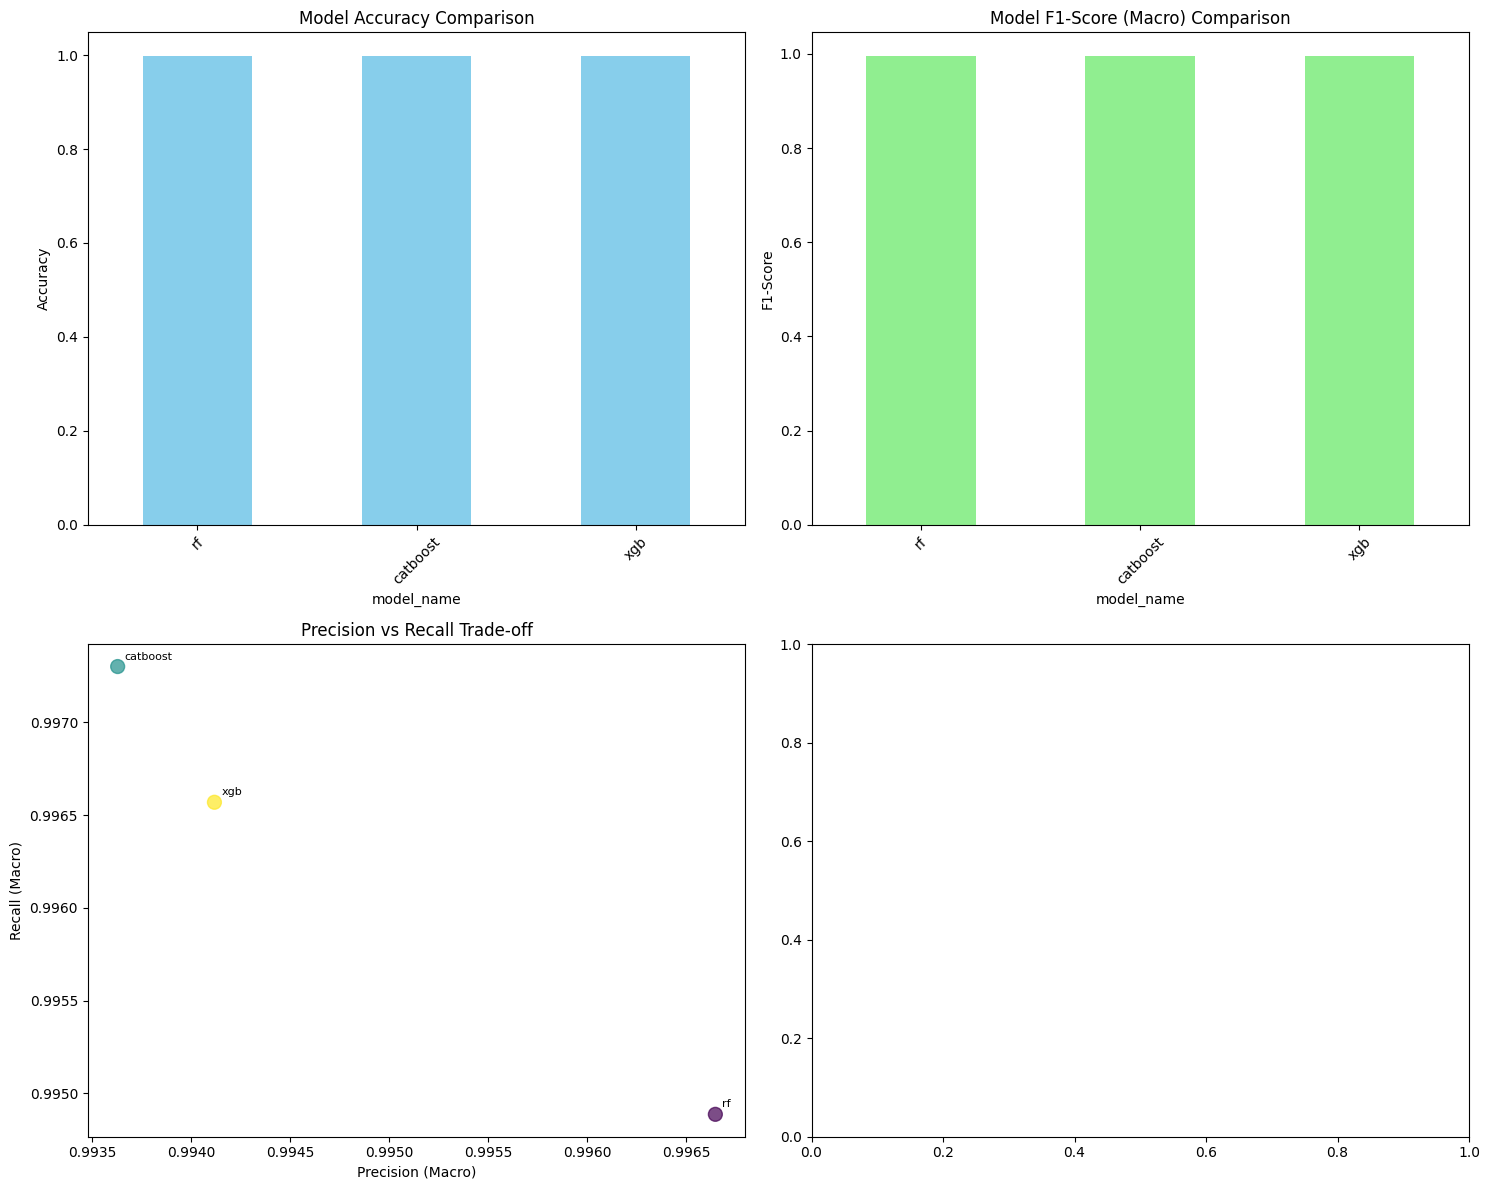

In [30]:
# Visualize model performance comparison
def plot_model_comparison(results_df):
    # Create visualizations for model performance comparison.
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Accuracy comparison
    results_df['accuracy'].plot(kind='bar', ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Model Accuracy Comparison')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. F1-Score comparison
    results_df['f1_macro'].plot(kind='bar', ax=axes[0,1], color='lightgreen')
    axes[0,1].set_title('Model F1-Score (Macro) Comparison')
    axes[0,1].set_ylabel('F1-Score')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Precision vs Recall
    axes[1,0].scatter(results_df['precision_macro'], results_df['recall_macro'],
                     s=100, alpha=0.7, c=range(len(results_df)), cmap='viridis')
    for i, model in enumerate(results_df.index):
        axes[1,0].annotate(model, (results_df['precision_macro'].iloc[i],
                                  results_df['recall_macro'].iloc[i]),
                          xytext=(5, 5), textcoords='offset points', fontsize=8)
    axes[1,0].set_xlabel('Precision (Macro)')
    axes[1,0].set_ylabel('Recall (Macro)')
    axes[1,0].set_title('Precision vs Recall Trade-off')

    # 4. Training time comparison
    # results_df['training_time'].plot(kind='bar', ax=axes[1,1], color='orange')
    # axes[1,1].set_title('Model Training Time Comparison')
    # axes[1,1].set_ylabel('Training Time (seconds)')
    # axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot comparison
plot_model_comparison(results_sorted)

## 6. Detailed Model Analysis

Analyze the best performing models in detail.


Best performing model: rf
F1-Score (Macro): 0.9958
Accuracy: 0.9985


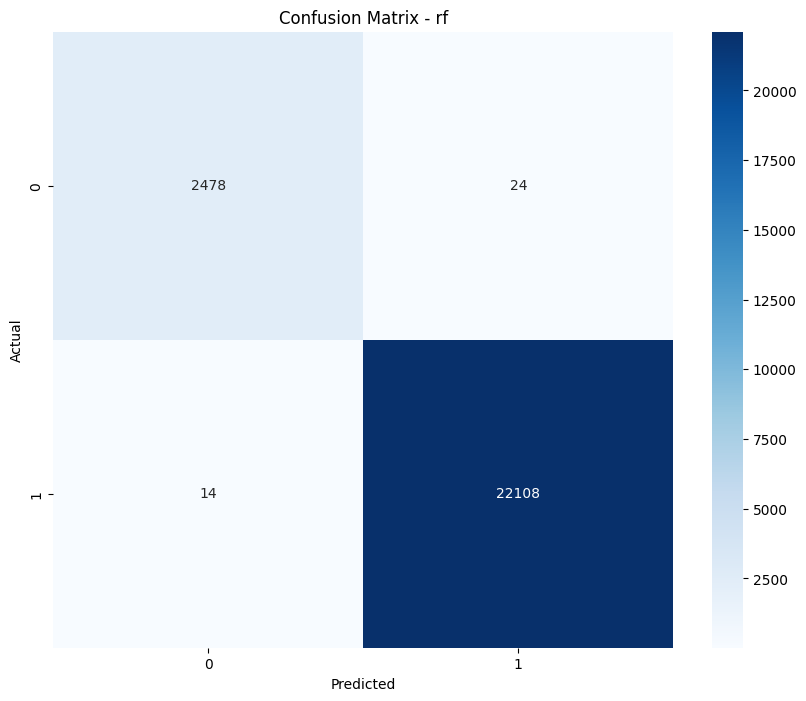

In [31]:
# Get the best model
trained_models={}
trained_models['xgb']=bestXGB
trained_models['rf']=bestRF
trained_models['catboost']=bestCatBoost
best_model_name = results_sorted.index[0]
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"F1-Score (Macro): {results_sorted.loc[best_model_name, 'f1_macro']:.4f}")
print(f"Accuracy: {results_sorted.loc[best_model_name, 'accuracy']:.4f}")

# Make predictions with best model
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test) if hasattr(best_model, 'predict_proba') else None

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(len(np.unique(y_test))),
            yticklabels=range(len(np.unique(y_test))))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Feature Importance Analysis

Analyze feature importance for tree-based models.



Feature Importance Analysis - xgb:


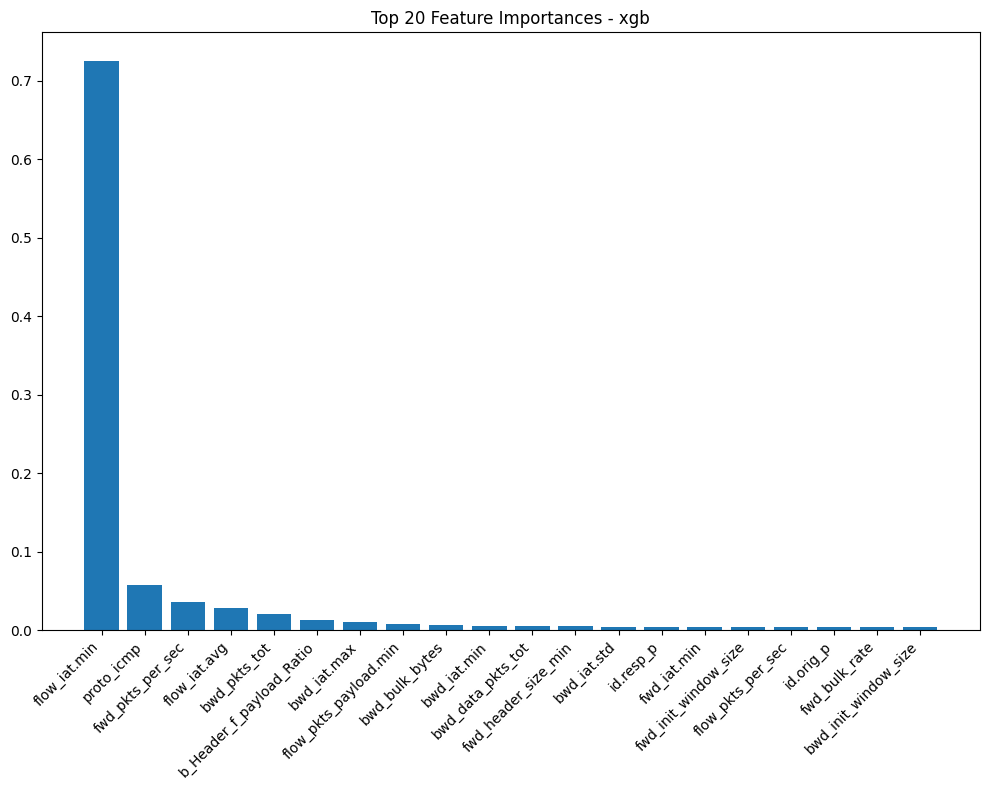


Top 10 Most Important Features:
                    feature  importance
0              flow_iat.min    0.725658
1                proto_icmp    0.058136
2          fwd_pkts_per_sec    0.035902
3              flow_iat.avg    0.028223
4              bwd_pkts_tot    0.020726
5  b_Header_f_payload_Ratio    0.013438
6               bwd_iat.max    0.010330
7     flow_pkts_payload.min    0.008115
8            bwd_bulk_bytes    0.006028
9               bwd_iat.min    0.005716

Feature Importance Analysis - rf:


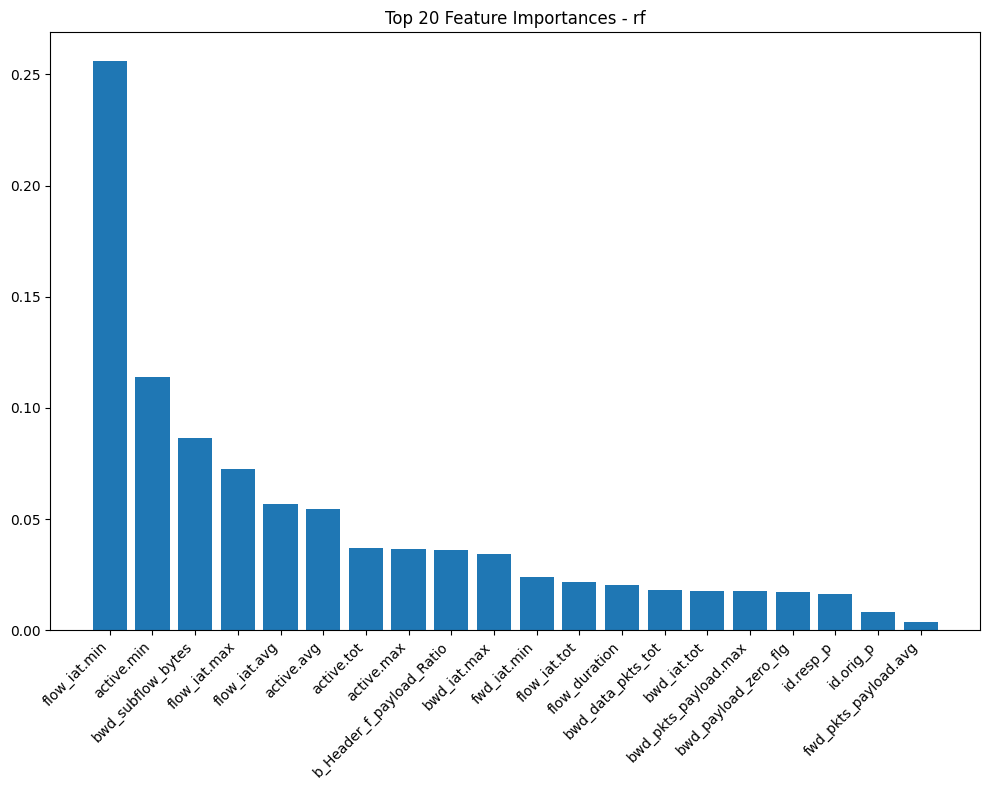


Top 10 Most Important Features:
                    feature  importance
0              flow_iat.min    0.256089
1                active.min    0.113759
2         bwd_subflow_bytes    0.086272
3              flow_iat.max    0.072415
4              flow_iat.avg    0.056620
5                active.avg    0.054516
6                active.tot    0.037065
7                active.max    0.036628
8  b_Header_f_payload_Ratio    0.036042
9               bwd_iat.max    0.034172

Feature Importance Analysis - catboost:


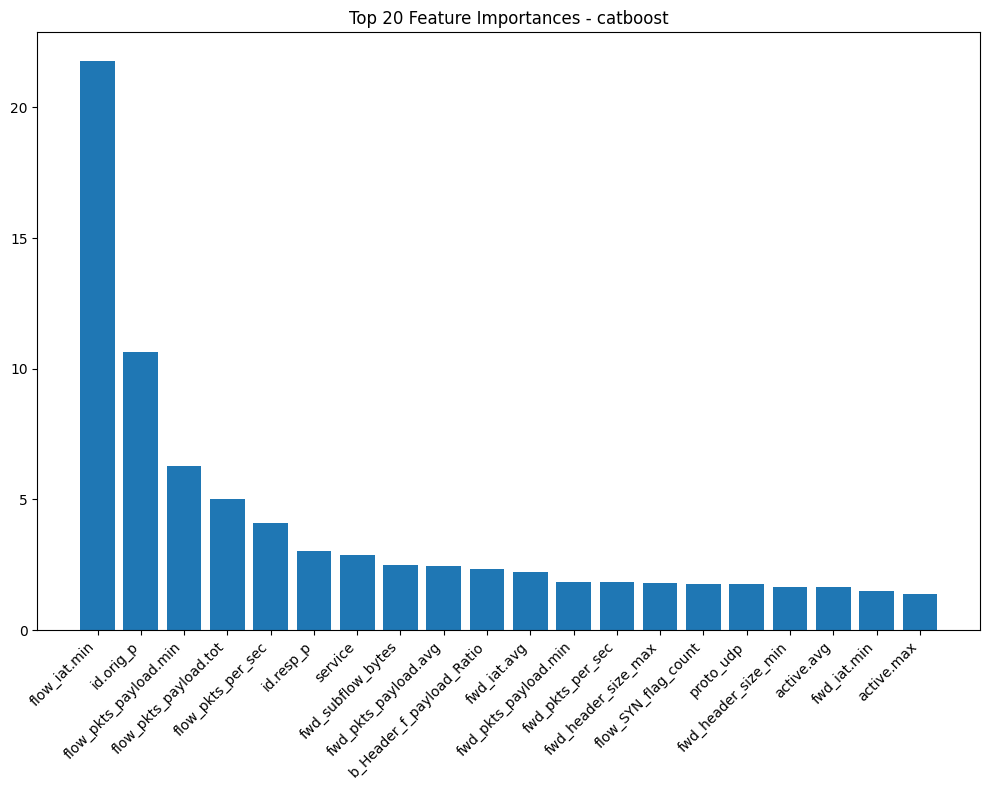


Top 10 Most Important Features:
                    feature  importance
0              flow_iat.min   21.786295
1                 id.orig_p   10.661339
2     flow_pkts_payload.min    6.263839
3     flow_pkts_payload.tot    5.016937
4         flow_pkts_per_sec    4.103063
5                 id.resp_p    3.028993
6                   service    2.879784
7         fwd_subflow_bytes    2.480308
8      fwd_pkts_payload.avg    2.443172
9  b_Header_f_payload_Ratio    2.321891


In [32]:
def plot_feature_importance(model, feature_names, model_name, top_n=20):
    # Plot feature importance for tree-based models.
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]

        plt.figure(figsize=(10, 8))
        plt.title(f'Top {top_n} Feature Importances - {model_name}')
        plt.bar(range(top_n), importances[indices])
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Return feature importance DataFrame
        feature_importance_df = pd.DataFrame({
            'feature': [feature_names[i] for i in indices],
            'importance': importances[indices]
        })
        return feature_importance_df
    else:
        print(f"{model_name} does not support feature importance analysis.")
        return None

feature_names = X_train.columns.tolist()

for model_name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        print(f"\nFeature Importance Analysis - {model_name}:")
        feature_importance_df = plot_feature_importance(model, feature_names, model_name)
        if feature_importance_df is not None:
            print("\nTop 10 Most Important Features:")
            print(feature_importance_df.head(10))


## 8. Model Saving and Inference Functions

Save the trained models and create inference functions.


In [33]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

def save_models(trained_models, results_df):
    # Save all trained models
    for model_name, model in trained_models.items():
        model_path = f'models/{model_name.lower()}_model.pkl'
        joblib.dump(model, model_path)
        print(f"Saved {model_name} to {model_path}")

    # Save results
    results_df.to_csv('models/model_performance_results.csv')
    print("Saved model performance results to models/model_performance_results.csv")

    # Save best model separately
    best_model_name = results_df.index[0]
    best_model = trained_models[best_model_name]
    joblib.dump(best_model, 'models/best_model.pkl')
    print(f"Saved best model ({best_model_name}) to models/best_model.pkl")

save_models(trained_models, results_sorted)

Saved xgb to models/xgb_model.pkl
Saved rf to models/rf_model.pkl
Saved catboost to models/catboost_model.pkl
Saved model performance results to models/model_performance_results.csv
Saved best model (rf) to models/best_model.pkl


## 9. Summary and Conclusions

Summarize the findings and provide recommendations.


In [34]:
print("\n" + "="*80)
print("ENSEMBLE ML MODELS FOR IOT IDS - FINAL SUMMARY")
print("="*80)

print(f"\nDataset Information:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Test samples: {X_test.shape[0]}")
print(f"- Features: {X_train.shape[1]}")
print(f"- Classes: {len(np.unique(y_train))}")

print(f"\nModels Trained: {len(trained_models)}")
for model_name in trained_models.keys():
    print(f"- {model_name}")

print(f"\nTop 3 Performing Models:")
for i, (model_name, row) in enumerate(results_sorted.head(3).iterrows()):
    print(f"{i+1}. {model_name}: F1-Score = {row['f1_macro']:.4f}, Accuracy = {row['accuracy']:.4f}")

print(f"\nBest Model: {best_model_name}")
print(f"- F1-Score (Macro): {results_sorted.loc[best_model_name, 'f1_macro']:.4f}")
print(f"- Accuracy: {results_sorted.loc[best_model_name, 'accuracy']:.4f}")
print(f"- Precision (Macro): {results_sorted.loc[best_model_name, 'precision_macro']:.4f}")
print(f"- Recall (Macro): {results_sorted.loc[best_model_name, 'recall_macro']:.4f}")
# print(f"- Training Time: {results_sorted.loc[best_model_name, 'training_time']:.2f} seconds")

print(f"\nFiles Saved:")
print(f"- Individual models: models/*_model.pkl")
print(f"- Best model: models/best_model.pkl")
print(f"- Performance results: models/model_performance_results.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


ENSEMBLE ML MODELS FOR IOT IDS - FINAL SUMMARY

Dataset Information:
- Training samples: 78794
- Test samples: 24624
- Features: 82
- Classes: 2

Models Trained: 3
- xgb
- rf
- catboost

Top 3 Performing Models:
1. rf: F1-Score = 0.9958, Accuracy = 0.9985
2. catboost: F1-Score = 0.9955, Accuracy = 0.9983
3. xgb: F1-Score = 0.9953, Accuracy = 0.9983

Best Model: rf
- F1-Score (Macro): 0.9958
- Accuracy: 0.9985
- Precision (Macro): 0.9966
- Recall (Macro): 0.9949

Files Saved:
- Individual models: models/*_model.pkl
- Best model: models/best_model.pkl
- Performance results: models/model_performance_results.csv

ANALYSIS COMPLETE
